# Monty and pydeno: two sandboxes, one host tool

A model that writes code usually wants the best language for each half of a job: Python for wrangling data, JavaScript for what only the JS ecosystem does well (here: a Vega-Lite chart). This notebook runs both halves without trusting either. The model's **Python** runs in Monty (pydantic's Python sandbox), the model's **JavaScript** runs in pydeno's `IsolatedRuntime` (worker process + OS sandbox), and both call the **same host tool** through **one shared call budget** -- neither can reach the notebook's files, network or environment.

```
pip install pydeno pydantic-monty
```


In [1]:
from __future__ import annotations

import asyncio
import pathlib

from pydeno import WEB_POLYFILLS, IsolatedRuntime, JavaScriptError, RuntimeConfig
from pydantic_monty import Monty, MontyRuntimeError

# This notebook runs with the repo root as its working directory, so the vendored
# Vega bundles are found the same way the script finds them relative to its own file.
def _repo_root() -> pathlib.Path:
    """Walk up from the current directory to find the pydeno checkout: this notebook is run
    with the repo root as its cwd when executed from the command line, but opening it directly
    in Jupyter normally starts in its own directory (examples/notebooks/) instead."""
    for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (candidate / "vendor" / "libs").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("run this notebook from inside a pydeno checkout")


ROOT = _repo_root()
LIBS = ROOT / "vendor" / "libs"


Host side: one tool, one budget, shared by both sandboxes.

In [2]:
SALES = [
    {"region": "North", "units": 120, "price": 9.5},
    {"region": "South", "units": 80, "price": 12.0},
    {"region": "East", "units": 200, "price": 7.25},
    {"region": "West", "units": 150, "price": 8.0},
    {"region": "North", "units": 60, "price": 10.0},
    {"region": "East", "units": 40, "price": 7.5},
]


class Budget:
    """Total tool calls the model may make this turn, whichever language it calls from."""

    def __init__(self, calls: int) -> None:
        self.total, self.left = calls, calls

    def tool(self, fn):
        def guarded(*args):
            if self.left <= 0:
                raise RuntimeError("tool budget exhausted")
            self.left -= 1
            return fn(*args)

        return guarded


budget = Budget(calls=5)
fetch_sales = budget.tool(lambda: SALES)


What the model wrote (hard-coded here; in real use it comes back from your LLM) -- one Python snippet, one JavaScript snippet, and the same reach-outside attempt in each language.

In [3]:
MODEL_PYTHON = """
totals = {}
for row in fetch_sales():                      # a host tool, called from the Python sandbox
    amount = row["units"] * row["price"]
    if row["region"] in totals:
        totals[row["region"]] += amount
    else:
        totals[row["region"]] = amount
best = None
for region in totals:
    if best is None or totals[region] > totals[best]:
        best = region
print(f"best region: {best} ({totals[best]:.0f})")
{"totals": totals, "best": best}               # the value of the last expression comes back
"""

MODEL_JAVASCRIPT = """
(async () => {
  const { totals, best } = getAnalysis();      // the Python result, handed over by the host
  const units = {};                            // the same tool, now called from JavaScript
  for (const r of fetch_sales()) units[r.region] = (units[r.region] || 0) + r.units;

  const spec = {
    $schema: 'https://vega.github.io/schema/vega-lite/v5.json',
    title: `Revenue by region (best: ${best})`,
    width: 320, height: 200,
    data: { values: Object.entries(totals).map(([region, revenue]) =>
      ({ region, revenue, units: units[region], best: region === best })) },
    mark: { type: 'bar', cornerRadiusEnd: 4 },
    encoding: {
      x: { field: 'region', type: 'nominal', axis: { labelAngle: 0 } },
      y: { field: 'revenue', type: 'quantitative' },
      color: { condition: { test: 'datum.best', value: '#2b8a3e' }, value: '#adb5bd' },
    },
  };
  const view = new vega.View(vega.parse(vegaLite.compile(spec).spec), { renderer: 'none' });
  return await view.toSVG();
})()
"""

# The same attempt in each language: reach outside. Neither sandbox lets it through.
NASTY_PYTHON = "open('/etc/passwd').read()"
NASTY_JAVASCRIPT = "fetch('https://example.com')"


Define the two run functions: one drives Monty, the other drives pydeno's `IsolatedRuntime`.

In [4]:
def run_python(pool: Monty) -> dict:
    with pool.checkout() as session:
        analysis = session.feed_run(
            MODEL_PYTHON,
            external_lookup={"fetch_sales": fetch_sales},
            print_callback=lambda stream, text: print(f"  [python] {text}", end=""),
        )
        try:
            session.feed_run(NASTY_PYTHON)
        except MontyRuntimeError as exc:
            print(f"  [python] refused: {str(exc).splitlines()[-1][:70]}")
    return analysis


async def run_javascript(analysis: dict) -> str:
    libs = "\n;\n".join(
        (LIBS / name).read_text()
        for name in ("vega-6.4.0.min.js", "vega-lite-6.4.3.min.js")
    )
    with IsolatedRuntime(
        RuntimeConfig(bootstrap=WEB_POLYFILLS), sandbox="require"
    ) as rt:
        rt.bind_function("getAnalysis", lambda: analysis)
        rt.bind_function("fetch_sales", fetch_sales)
        await rt.eval_async(libs + "\n;0", timeout=30)
        try:
            rt.eval(NASTY_JAVASCRIPT)
        except JavaScriptError as exc:
            print(f"  [js]     refused: {exc}"[:90])
        svg = await rt.eval_async(MODEL_JAVASCRIPT, timeout=30)
        print(f"  [js]     sandbox: {rt.sandbox}")
    return svg


Step 1: run the Python half in Monty.

In [5]:
print("1. Python half, in Monty")
with Monty() as pool:
    analysis = run_python(pool)
analysis


1. Python half, in Monty
  [python] best region: East (1750)
  [python] refused: PermissionError: Permission denied: '/etc/passwd'


{'totals': {'North': 1740.0, 'South': 960.0, 'East': 1750.0, 'West': 1200.0},
 'best': 'East'}

Step 2: run the JavaScript half in pydeno, writing the chart to `sales.svg`.

In [6]:
print("2. JavaScript half, in pydeno")
# The script uses asyncio.run(); a notebook cell already runs inside an event loop
# (ipykernel), so we await the coroutine directly instead -- same coroutine, same behavior.
svg = await run_javascript(analysis)
pathlib.Path("sales.svg").write_text(svg)
print(
    f"3. wrote sales.svg ({len(svg)} bytes); tool calls used: {budget.total - budget.left} of {budget.total}"
)


2. JavaScript half, in pydeno


  [js]     refused: Evaluation failed: ReferenceError: fetch is not defined
  [js]     sandbox: seatbelt
3. wrote sales.svg (11021 bytes); tool calls used: 2 of 5


Step 3: show the chart inline.

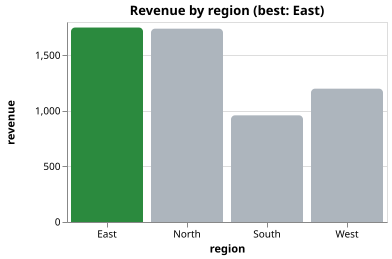

In [7]:
from IPython.display import SVG, display

display(SVG(filename="sales.svg"))
